## Setting Directories and Paths

In [ ]:
import os
CUSTOM_MODEL_NAME = 'my_ssd_mobnet'
PRETRAINED_MODEL_NAME = 'ssd_mobilenet_v2_fpnlite_320x320_coco17_tpu-8'
PRETRAINED_MODEL_URL = 'http://download.tensorflow.org/models/object_detection/tf2/20200711/ssd_mobilenet_v2_fpnlite_320x320_coco17_tpu-8.tar.gz'
TF_RECORD_SCRIPT_NAME = 'generate_tfrecord.py'
LABEL_MAP_NAME = 'label_map.pbtxt'
paths = {
    'WORKSPACE_PATH': os.path.join('Tensorflow', 'workspace'),
    'SCRIPTS_PATH': os.path.join('Tensorflow','scripts'),
    'APIMODEL_PATH': os.path.join('Tensorflow','models'),
    'ANNOTATION_PATH': os.path.join('Tensorflow', 'workspace','annotations'),
    'IMAGE_PATH': os.path.join('Tensorflow', 'workspace','images'),
    'MODEL_PATH': os.path.join('Tensorflow', 'workspace','models'),
    'PRETRAINED_MODEL_PATH': os.path.join('Tensorflow', 'workspace','pre-trained-models'),
    'CHECKPOINT_PATH': os.path.join('Tensorflow', 'workspace','models',CUSTOM_MODEL_NAME),
    'OUTPUT_PATH': os.path.join('Tensorflow', 'workspace','models',CUSTOM_MODEL_NAME, 'export'),
    'TFJS_PATH':os.path.join('Tensorflow', 'workspace','models',CUSTOM_MODEL_NAME, 'tfjsexport'),
    'TFLITE_PATH':os.path.join('Tensorflow', 'workspace','models',CUSTOM_MODEL_NAME, 'tfliteexport'),
    'PROTOC_PATH':os.path.join('Tensorflow','protoc')
 }
files = {
    'PIPELINE_CONFIG':os.path.join('Tensorflow', 'workspace','models', CUSTOM_MODEL_NAME, 'pipeline.config'),
    'TF_RECORD_SCRIPT': os.path.join(paths['SCRIPTS_PATH'], TF_RECORD_SCRIPT_NAME),
    'LABELMAP': os.path.join(paths['ANNOTATION_PATH'], LABEL_MAP_NAME)
}

In [ ]:
for path in paths.values():
    if not os.path.exists(path):
        if os.name == 'posix':
            !mkdir -p {path}
        if os.name == 'nt':
            !mkdir {path}


## Cloning Detection API and Installing TF Models Pretrained Models

In [ ]:
if not os.path.exists(os.path.join(paths['APIMODEL_PATH'], 'research', 'object_detection')):
    !git clone https://github.com/tensorflow/models {paths['APIMODEL_PATH']}


Cloning into 'Tensorflow/models'...
remote: Enumerating objects: 99321, done.
remote: Counting objects: 100% (87/87), done.
remote: Compressing objects: 100% (46/46), done.
remote: Total 99321 (delta 58), reused 41 (delta 41), pack-reused 99234 (from 5)
Receiving objects: 100% (99321/99321), 623.00 MiB | 27.06 MiB/s, done.
Resolving deltas: 100% (72148/72148), done.


In [ ]:
# Install Tensorflow Object Detection
if os.name=='posix':
    !apt-get install protobuf-compiler
    !cd Tensorflow/models/research && protoc object_detection/protos/*.proto --python_out=. && cp object_detection/packages/tf2/setup.py . && python -m pip install .

if os.name=='nt':
    url="https://github.com/protocolbuffers/protobuf/releases/download/v3.15.6/protoc-3.15.6-win64.zip"
    wget.download(url)
    !move protoc-3.15.6-win64.zip {paths['PROTOC_PATH']}
    !cd {paths['PROTOC_PATH']} && tar -xf protoc-3.15.6-win64.zip
    os.environ['PATH'] += os.pathsep + os.path.abspath(os.path.join(paths['PROTOC_PATH'], 'bin'))
    !cd Tensorflow/models/research && protoc object_detection/protos/*.proto --python_out=. && copy object_detection\\packages\\tf2\\setup.py setup.py && python setup.py build && python setup.py install
    !cd Tensorflow/models/research/slim && pip install -e .


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
protobuf-compiler is already the newest version (3.12.4-1ubuntu7.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 20 not upgraded.
Processing /content/Tensorflow/models/research
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.4/55.4 kB 5.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 4.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.7/89.7 kB 8.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 152.0/152.0 kB 11.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 3.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
pip install protobuf==3.20.*

  Using cached protobuf-3.20.3-py2.py3-none-any.whl.metadata (720 bytes)
Using cached protobuf-3.20.3-py2.py3-none-any.whl (162 kB)
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.3
    Uninstalling protobuf-5.29.3:
      Successfully uninstalled protobuf-5.29.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ydf 0.10.0 requires protobuf>=5.29.1, but you have protobuf 3.20.3 which is incompatible.
grpcio-status 1.62.3 requires protobuf>=4.21.6, but you have protobuf 3.20.3 which is incompatible.
tensorflow-metadata 1.16.1 requires protobuf<6.0.0dev,>=4.25.2; python_version >= "3.11", but you have protobuf 3.20.3 which is incompatible.


In [ ]:
pip install tensorflow==2.13.1


  Using cached tensorflow-2.13.1-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (3.4 kB)
  Using cached keras-2.13.1-py3-none-any.whl.metadata (2.4 kB)
  Using cached numpy-1.24.3-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (5.6 kB)
  Using cached tensorboard-2.13.0-py3-none-any.whl.metadata (1.8 kB)
Using cached tensorflow-2.13.1-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (479.7 MB)
Using cached keras-2.13.1-py3-none-any.whl (1.7 MB)
Using cached numpy-1.24.3-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (17.3 MB)
Using cached tensorboard-2.13.0-py3-none-any.whl (5.6 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: keras
    Found existing installation: keras 3.8.0
    Uninstalling keras-3.8.0:
      Successfully uninstalled keras-3.8.0
  Attempting uninstall: tensorboard
    Found exist

In [ ]:
VERIFICATION_SCRIPT = os.path.join(paths['APIMODEL_PATH'], 'research', 'object_detection', 'builders', 'model_builder_tf2_test.py')
# Verify Installation
!python {VERIFICATION_SCRIPT}


2025-02-16 13:16:08.227431: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
2025-02-16 13:16:10.926046: W tensorflow/core/common_runtime/gpu/gpu_device.cc:1960] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
Running tests under Python 3.11.11: /usr/bin/python3
[ RUN      ] ModelBuilderTF2Test.test_create_center_net_deepmac
W0216 13:16:10.960150 137674217349120 batch_normalization.py:1531] `tf.keras.layers.experimental.SyncBatchNormalization` endpoint is deprecated and will be removed in a future release. Please use `tf.keras.layers.BatchNormalization` with parameter `synchronized` set to True.
W0216 13:16:11.386881 137674217349120 model_builder.py:1112] Building experimental DeepMA

In [ ]:
if os.name =='posix':
    !wget {PRETRAINED_MODEL_URL}
    !mv {PRETRAINED_MODEL_NAME+'.tar.gz'} {paths['PRETRAINED_MODEL_PATH']}
    !cd {paths['PRETRAINED_MODEL_PATH']} && tar -zxvf {PRETRAINED_MODEL_NAME+'.tar.gz'}
if os.name == 'nt':
    wget.download(PRETRAINED_MODEL_URL)
    !move {PRETRAINED_MODEL_NAME+'.tar.gz'} {paths['PRETRAINED_MODEL_PATH']}
    !cd {paths['PRETRAINED_MODEL_PATH']} && tar -zxvf {PRETRAINED_MODEL_NAME+'.tar.gz'}


--2025-02-16 13:22:47--  http://download.tensorflow.org/models/object_detection/tf2/20200711/ssd_mobilenet_v2_fpnlite_320x320_coco17_tpu-8.tar.gz
Resolving download.tensorflow.org (download.tensorflow.org)... 173.194.216.207, 74.125.26.207, 108.177.11.207, ...
Connecting to download.tensorflow.org (download.tensorflow.org)|173.194.216.207|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 20515344 (20M) [application/x-tar]
Saving to: ‘ssd_mobilenet_v2_fpnlite_320x320_coco17_tpu-8.tar.gz’

ssd_mobilenet_v2_fp 100%[===================>]  19.56M  --.-KB/s    in 0.1s    

2025-02-16 13:22:47 (171 MB/s) - ‘ssd_mobilenet_v2_fpnlite_320x320_coco17_tpu-8.tar.gz’ saved [20515344/20515344]

ssd_mobilenet_v2_fpnlite_320x320_coco17_tpu-8/
ssd_mobilenet_v2_fpnlite_320x320_coco17_tpu-8/checkpoint/
ssd_mobilenet_v2_fpnlite_320x320_coco17_tpu-8/checkpoint/ckpt-0.data-00000-of-00001
ssd_mobilenet_v2_fpnlite_320x320_coco17_tpu-8/checkpoint/checkpoint
ssd_mobilenet_v2_fpnlite_320x32

## Label Map

In [ ]:
labels = [{'name':'left_hand', 'id':1}, {'name':'right_hand', 'id':2}, {'name':'notebook', 'id':3}, {'name':'phone', 'id':4}]

with open(files['LABELMAP'], 'w') as f:
    for label in labels:
        f.write('item { \n')
        f.write('\tname:\'{}\'\n'.format(label['name']))
        f.write('\tid:{}\n'.format(label['id']))
        f.write('}\n')

## TF Record

In [ ]:

ARCHIVE_FILES = os.path.join(paths['IMAGE_PATH'], 'archive.tar.gz')
if os.path.exists(ARCHIVE_FILES):
  !tar -zxvf {ARCHIVE_FILES}


Tensorflow/workspace/images/train/
Tensorflow/workspace/images/train/.ipynb_checkpoints/
Tensorflow/workspace/images/train/left_hand.bd17456d-e30a-11ef-9107-18473da52c96.jpg
Tensorflow/workspace/images/train/left_hand.bd17456d-e30a-11ef-9107-18473da52c96.xml
Tensorflow/workspace/images/train/left_hand.be4f7245-e30a-11ef-aca7-18473da52c96.jpg
Tensorflow/workspace/images/train/left_hand.be4f7245-e30a-11ef-aca7-18473da52c96.xml
Tensorflow/workspace/images/train/left_hand.bf8773af-e30a-11ef-bd54-18473da52c96.jpg
Tensorflow/workspace/images/train/left_hand.bf8773af-e30a-11ef-bd54-18473da52c96.xml
Tensorflow/workspace/images/train/left_hand.c0bdccc9-e30a-11ef-8490-18473da52c96.jpg
Tensorflow/workspace/images/train/left_hand.c0bdccc9-e30a-11ef-8490-18473da52c96.xml
Tensorflow/workspace/images/train/left_hand.c1f268db-e30a-11ef-b489-18473da52c96.jpg
Tensorflow/workspace/images/train/left_hand.c1f268db-e30a-11ef-b489-18473da52c96.xml
Tensorflow/workspace/images/train/left_hand.c32886ac-e30a-11e

In [ ]:
if not os.path.exists(files['TF_RECORD_SCRIPT']):
    !git clone https://github.com/nicknochnack/GenerateTFRecord {paths['SCRIPTS_PATH']}

Cloning into 'Tensorflow/scripts'...
remote: Enumerating objects: 3, done.
remote: Counting objects: 100% (3/3), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 3 (delta 0), reused 1 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (3/3), done.


In [ ]:
!python {files['TF_RECORD_SCRIPT']} -x {os.path.join(paths['IMAGE_PATH'], 'train')} -l {files['LABELMAP']} -o {os.path.join(paths['ANNOTATION_PATH'], 'train.record')}
!python {files['TF_RECORD_SCRIPT']} -x {os.path.join(paths['IMAGE_PATH'], 'test')} -l {files['LABELMAP']} -o {os.path.join(paths['ANNOTATION_PATH'], 'test.record')}


Successfully created the TFRecord file: Tensorflow/workspace/annotations/train.record
Successfully created the TFRecord file: Tensorflow/workspace/annotations/test.record


## Fine-Tuning

In [ ]:
if os.name =='posix':
    !cp {os.path.join(paths['PRETRAINED_MODEL_PATH'], PRETRAINED_MODEL_NAME, 'pipeline.config')} {os.path.join(paths['CHECKPOINT_PATH'])}
if os.name == 'nt':
    !copy {os.path.join(paths['PRETRAINED_MODEL_PATH'], PRETRAINED_MODEL_NAME, 'pipeline.config')} {os.path.join(paths['CHECKPOINT_PATH'])}


In [ ]:
import tensorflow as tf
from object_detection.utils import config_util
from object_detection.protos import pipeline_pb2
from google.protobuf import text_format
config = config_util.get_configs_from_pipeline_file(files['PIPELINE_CONFIG'])

In [ ]:
config

{'model': ssd {
   num_classes: 90
   image_resizer {
     fixed_shape_resizer {
       height: 320
       width: 320
     }
   }
   feature_extractor {
     type: "ssd_mobilenet_v2_fpn_keras"
     depth_multiplier: 1.0
     min_depth: 16
     conv_hyperparams {
       regularizer {
         l2_regularizer {
           weight: 4e-05
         }
       }
       initializer {
         random_normal_initializer {
           mean: 0.0
           stddev: 0.01
         }
       }
       activation: RELU_6
       batch_norm {
         decay: 0.997
         scale: true
         epsilon: 0.001
       }
     }
     use_depthwise: true
     override_base_feature_extractor_hyperparams: true
     fpn {
       min_level: 3
       max_level: 7
       additional_layer_depth: 128
     }
   }
   box_coder {
     faster_rcnn_box_coder {
       y_scale: 10.0
       x_scale: 10.0
       height_scale: 5.0
       width_scale: 5.0
     }
   }
   matcher {
     argmax_matcher {
       matched_threshold: 0.5
   

In [ ]:
pipeline_config = pipeline_pb2.TrainEvalPipelineConfig()
with tf.io.gfile.GFile(files['PIPELINE_CONFIG'], "r") as f:
    proto_str = f.read()
    text_format.Merge(proto_str, pipeline_config)

In [ ]:
pipeline_config.model.ssd.num_classes = len(labels)
pipeline_config.train_config.batch_size = 4
pipeline_config.train_config.fine_tune_checkpoint = os.path.join(paths['PRETRAINED_MODEL_PATH'], PRETRAINED_MODEL_NAME, 'checkpoint', 'ckpt-0')
pipeline_config.train_config.fine_tune_checkpoint_type = "detection"
pipeline_config.train_input_reader.label_map_path= files['LABELMAP']
pipeline_config.train_input_reader.tf_record_input_reader.input_path[:] = [os.path.join(paths['ANNOTATION_PATH'], 'train.record')]
pipeline_config.eval_input_reader[0].label_map_path = files['LABELMAP']
pipeline_config.eval_input_reader[0].tf_record_input_reader.input_path[:] = [os.path.join(paths['ANNOTATION_PATH'], 'test.record')]


In [ ]:
config_text = text_format.MessageToString(pipeline_config)
with tf.io.gfile.GFile(files['PIPELINE_CONFIG'], "wb") as f:
    f.write(config_text)


## Training Model

In [ ]:
TRAINING_SCRIPT = os.path.join(paths['APIMODEL_PATH'], 'research', 'object_detection', 'model_main_tf2.py')


In [ ]:
command = "python {} --model_dir={} --pipeline_config_path={} --num_train_steps=2000".format(TRAINING_SCRIPT, paths['CHECKPOINT_PATH'],files['PIPELINE_CONFIG'])


In [ ]:
!{command}

2025-02-16 13:23:54.060777: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
2025-02-16 13:23:58.240860: W tensorflow/core/common_runtime/gpu/gpu_device.cc:1960] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:CPU:0',)
I0216 13:23:58.242312 133707455365120 mirrored_strategy.py:419] Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:CPU:0',)
INFO:tensorflow:Maybe overwriting train_steps: 2000
I0216 13:23:58.268991 133707455365120 config_util.py:552] Maybe overwriting train_steps: 2000
INFO:tensorflow:Maybe overwriting use_bfloat16: False
I0216 13:23:58.269190 13370745

In [ ]:
drive_path = "/content/drive/My Drive/Tensorflow_Backup"

backup_paths = {
    'CHECKPOINT_BACKUP': os.path.join(drive_path, 'checkpoints'),
    'MODEL_BACKUP': os.path.join(drive_path, 'models'),
    'ANNOTATION_BACKUP': os.path.join(drive_path, 'annotations'),
    'PIPELINE_CONFIG_BACKUP': os.path.join(drive_path, 'pipeline_config'),
}


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
os.makedirs(drive_path)
os.makedirs(backup_paths['CHECKPOINT_BACKUP'])
os.makedirs(backup_paths['MODEL_BACKUP'])
os.makedirs(backup_paths['ANNOTATION_BACKUP'])
os.makedirs(backup_paths['PIPELINE_CONFIG_BACKUP'])

In [ ]:
import os

# Ensure the backup directories exist
for path in backup_paths.values():
    os.makedirs(path, exist_ok=True)  # Creates the directory if it doesn’t exist

# Now run the copy commands
!cp -r {paths['CHECKPOINT_PATH']} {backup_paths['CHECKPOINT_BACKUP']}
!cp -r {paths['MODEL_PATH']} {backup_paths['MODEL_BACKUP']}
!cp -r {paths['ANNOTATION_PATH']} {backup_paths['ANNOTATION_BACKUP']}
!cp {files['PIPELINE_CONFIG']} {backup_paths['PIPELINE_CONFIG_BACKUP']}


cp: target 'Drive/Tensorflow_Backup/checkpoints' is not a directory
cp: target 'Drive/Tensorflow_Backup/models' is not a directory
cp: target 'Drive/Tensorflow_Backup/annotations' is not a directory
cp: target 'Drive/Tensorflow_Backup/pipeline_config' is not a directory


In [ ]:
print(paths['CHECKPOINT_PATH'])
print(backup_paths['CHECKPOINT_BACKUP'])


Tensorflow/workspace/models/my_ssd_mobnet
/content/drive/My Drive/Tensorflow_Backup/checkpoints


In [ ]:
import os
print(os.path.exists(backup_paths['CHECKPOINT_BACKUP']))  # Should return True


True


In [ ]:
!cp -r {paths['CHECKPOINT_PATH']} {backup_paths['CHECKPOINT_BACKUP']}
!cp -r {paths['MODEL_PATH']} {backup_paths['MODEL_BACKUP']}
!cp -r {paths['ANNOTATION_PATH']} {backup_paths['ANNOTATION_BACKUP']}
!cp {files['PIPELINE_CONFIG']} {backup_paths['PIPELINE_CONFIG_BACKUP']}


cp: target 'Drive/Tensorflow_Backup/checkpoints' is not a directory
cp: target 'Drive/Tensorflow_Backup/models' is not a directory
cp: target 'Drive/Tensorflow_Backup/annotations' is not a directory
cp: target 'Drive/Tensorflow_Backup/pipeline_config' is not a directory


In [ ]:
import os
import tensorflow as tf
from object_detection.utils import label_map_util
from object_detection.utils import visualization_utils as viz_utils
from object_detection.builders import model_builder
from object_detection.utils import config_util

In [ ]:
!cp -r "/content/drive/My Drive/Tensorflow_Backup/models/" {paths['MODEL_PATH']}
!cp -r "/content/drive/My Drive/Tensorflow_Backup/checkpoints/" {paths['CHECKPOINT_PATH']}
!cp -r "/content/drive/My Drive/Tensorflow_Backup/annotations/" {paths['ANNOTATION_PATH']}
!cp "/content/drive/My Drive/Tensorflow_Backup/pipeline_config" {files['PIPELINE_CONFIG']}


cp: -r not specified; omitting directory '/content/drive/My Drive/Tensorflow_Backup/pipeline_config'


In [ ]:
!cp "/content/drive/My Drive/Tensorflow_Backup/pipeline_config/pipeline.config" {files['PIPELINE_CONFIG']}

cp: cannot stat '/content/drive/My Drive/Tensorflow_Backup/pipeline.config': No such file or directory


## Loading Trained Model From Checkpoint

In [ ]:
# Restore checkpoint
ckpt = tf.compat.v2.train.Checkpoint(model=detection_model)
# Check if ckpt-5 exists, if not, try ckpt-0 or the latest available checkpoint
checkpoint_path = os.path.join(paths['CHECKPOINT_PATH'], 'ckpt-5')
if not tf.io.gfile.exists(checkpoint_path + '.index'):
    checkpoint_path = tf.train.latest_checkpoint(paths['CHECKPOINT_PATH'])
    print(f"Using checkpoint: {checkpoint_path}")
ckpt.restore(checkpoint_path).expect_partial()

Using checkpoint: Tensorflow/workspace/models/my_ssd_mobnet/ckpt-3


In [ ]:
@tf.function
def detect_fn(image):
    image, shapes = detection_model.preprocess(image)
    prediction_dict = detection_model.predict(image, shapes)
    detections = detection_model.postprocess(prediction_dict, shapes)
    return detections


In [ ]:
# Move model loading and checkpoint restoration outside of the detect_fn

# Load the model and restore checkpoint outside the function
configs = config_util.get_configs_from_pipeline_file(files['PIPELINE_CONFIG'])
detection_model = model_builder.build(model_config=configs['model'], is_training=False)

# Restore checkpoint
ckpt = tf.compat.v2.train.Checkpoint(model=detection_model)
checkpoint_path = os.path.join(paths['CHECKPOINT_PATH'], 'ckpt-5')
if not tf.io.gfile.exists(checkpoint_path + '.index'):
    checkpoint_path = tf.train.latest_checkpoint(paths['CHECKPOINT_PATH'])
    print(f"Using checkpoint: {checkpoint_path}")
ckpt.restore(checkpoint_path).expect_partial()

@tf.function
def detect_fn(image):
    image, shapes = detection_model.preprocess(image)
    prediction_dict = detection_model.predict(image, shapes)
    detections = detection_model.postprocess(prediction_dict, shapes)
    return detections

Using checkpoint: Tensorflow/workspace/models/my_ssd_mobnet/ckpt-3


## Object Detection

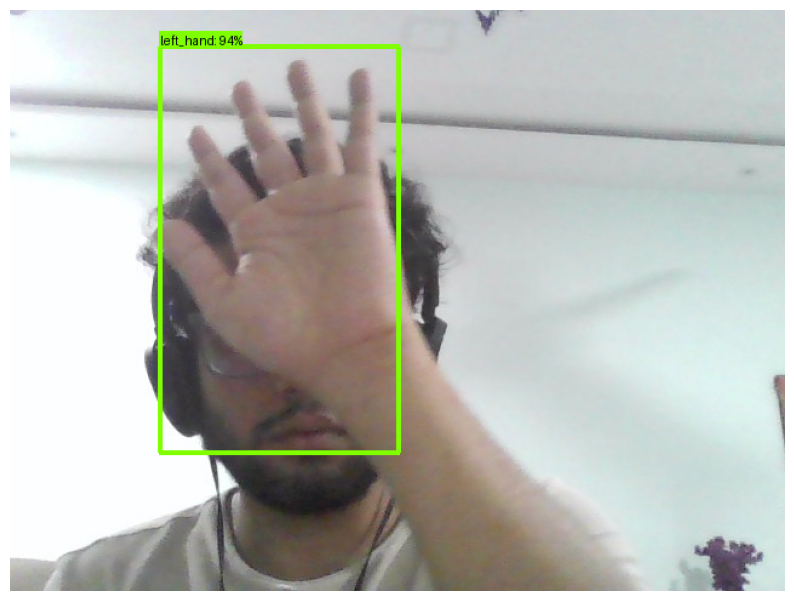

In [ ]:
import cv2
import numpy as np
import tensorflow as tf
import os
from matplotlib import pyplot as plt
%matplotlib inline

# Load Label Map
category_index = label_map_util.create_category_index_from_labelmap(files['LABELMAP'])

# Load Image and Ensure it's RGB
IMAGE_PATH = os.path.join(paths['IMAGE_PATH'], 'test', 'left_hand.cb986d96-e30a-11ef-aca2-18473da52c96.jpg')
img = cv2.imread(IMAGE_PATH)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert to RGB
image_np = np.array(img, dtype=np.float32)  # Ensure NumPy array with float32

# Ensure Image Shape is Correct
if image_np.ndim != 3:
    raise ValueError(f"Unexpected image shape: {image_np.shape}. Expected (H, W, C).")

# Expand dims for batch input
input_tensor = tf.convert_to_tensor(np.expand_dims(image_np, axis=0), dtype=tf.float32)

# Run Detection
detections = detect_fn(input_tensor)

# Process detections
num_detections = int(detections.pop('num_detections'))
detections = {key: value[0, :num_detections].numpy() for key, value in detections.items()}
detections['num_detections'] = num_detections

# Convert classes to int
detections['detection_classes'] = detections['detection_classes'].astype(np.int64)

# Visualization
label_id_offset = 1
image_np_with_detections = image_np.copy()

viz_utils.visualize_boxes_and_labels_on_image_array(
    image_np_with_detections,
    detections['detection_boxes'],
    detections['detection_classes'] + label_id_offset,
    detections['detection_scores'],
    category_index,
    use_normalized_coordinates=True,
    max_boxes_to_draw=5,
    min_score_thresh=0.8,
    agnostic_mode=False
)

# Display the image
plt.figure(figsize=(10, 8))
plt.imshow(image_np_with_detections.astype(np.uint8))
plt.axis('off')
plt.show()


## Freezing Graph and Exporting Model

In [ ]:
FREEZE_SCRIPT = os.path.join(paths['APIMODEL_PATH'], 'research', 'object_detection', 'exporter_main_v2.py ')
command = "python {} --input_type=image_tensor --pipeline_config_path={} --trained_checkpoint_dir={} --output_directory={}".format(FREEZE_SCRIPT ,files['PIPELINE_CONFIG'], paths['CHECKPOINT_PATH'], paths['OUTPUT_PATH'])
print(command)
!python Tensorflow\models\research\object_detection\exporter_main_v2.py  --input_type=image_tensor --pipeline_config_path=Tensorflow\workspace\models\my_ssd_mobnet\pipeline.config --trained_checkpoint_dir=Tensorflow\workspace\models\my_ssd_mobnet --output_directory=Tensorflow\workspace\models\my_ssd_mobnet\export
!{command}


python Tensorflow/models/research/object_detection/exporter_main_v2.py  --input_type=image_tensor --pipeline_config_path=Tensorflow/workspace/models/my_ssd_mobnet/pipeline.config --trained_checkpoint_dir=Tensorflow/workspace/models/my_ssd_mobnet --output_directory=Tensorflow/workspace/models/my_ssd_mobnet/export
python3: can't open file '/content/Tensorflowmodelsresearchobject_detectionexporter_main_v2.py': [Errno 2] No such file or directory
2025-02-16 14:50:09.324018: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
2025-02-16 14:50:12.152219: W tensorflow/core/common_runtime/gpu/gpu_device.cc:1960] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
Instructions for updating:
back_pro

In [ ]:
!pip install tensorflowjs


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.1/89.1 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.9/15.9 MB 89.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 615.4/615.4 MB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 60.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.5/19.5 MB 89.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 97.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 103.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.7/319.7 kB 25.5 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 3.20.3
    Uninstalling protobuf-3.20.3:
      Successfully uninstalled protobuf-3.20.3
  Attempting uninstall: packaging
    Found exis

In [ ]:
command = "tensorflowjs_converter --input_format=tf_saved_model --output_node_names='detection_boxes,detection_classes,detection_features,detection_multiclass_scores,detection_scores,num_detections,raw_detection_boxes,raw_detection_scores' --output_format=tfjs_graph_model --signature_name=serving_default {} {}".format(os.path.join(paths['OUTPUT_PATH'], 'saved_model'), paths['TFJS_PATH'])
print(command)


tensorflowjs_converter --input_format=tf_saved_model --output_node_names='detection_boxes,detection_classes,detection_features,detection_multiclass_scores,detection_scores,num_detections,raw_detection_boxes,raw_detection_scores' --output_format=tfjs_graph_model --signature_name=serving_default Tensorflow/workspace/models/my_ssd_mobnet/export/saved_model Tensorflow/workspace/models/my_ssd_mobnet/tfjsexport


In [ ]:
!{command}


2025-02-16 14:52:19.092370: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1739717539.113346   24239 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1739717539.120554   24239 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
🌲 Try https://ydf.readthedocs.io, the successor of TensorFlow Decision Forests with more features and faster training!
2025-02-16 14:52:33.168467: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1739717553.177951   24239 gpu_device.cc:2022] Created device /job:localhost/replica:0/task

In [ ]:
TFLITE_SCRIPT = os.path.join(paths['APIMODEL_PATH'], 'research', 'object_detection', 'export_tflite_graph_tf2.py ')
command = "python {} --pipeline_config_path={} --trained_checkpoint_dir={} --output_directory={}".format(TFLITE_SCRIPT ,files['PIPELINE_CONFIG'], paths['CHECKPOINT_PATH'], paths['TFLITE_PATH'])


In [ ]:
!{command}


2025-02-16 14:56:44.872645: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-02-16 14:56:44.960363: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-02-16 14:56:44.961168: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-02-16 14:56:47.825223: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
2025-02-16 14:56:51.618061: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Do

In [ ]:
FROZEN_TFLITE_PATH = os.path.join(paths['TFLITE_PATH'], 'saved_model')
TFLITE_MODEL = os.path.join(paths['TFLITE_PATH'], 'saved_model', 'detect.tflite')
command = "tflite_convert \
--saved_model_dir={} \
--output_file={} \
--input_shapes=1,300,300,3 \
--input_arrays=normalized_input_image_tensor \
--output_arrays='TFLite_Detection_PostProcess','TFLite_Detection_PostProcess:1','TFLite_Detection_PostProcess:2','TFLite_Detection_PostProcess:3' \
--inference_type=FLOAT \
--allow_custom_ops".format(FROZEN_TFLITE_PATH, TFLITE_MODEL, )


In [ ]:
!{command}


2025-02-16 14:57:42.219408: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-02-16 14:57:42.308155: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-02-16 14:57:42.308853: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-02-16 14:57:44.041750: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
2025-02-16 14:57:45.657836: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Do

In [ ]:
!tar -czf models.tar.gz {paths['CHECKPOINT_PATH']}


In [ ]:
!zip -r exported_model.zip {paths['OUTPUT_PATH']}


  adding: Tensorflow/workspace/models/my_ssd_mobnet/export/ (stored 0%)
  adding: Tensorflow/workspace/models/my_ssd_mobnet/export/pipeline.config (deflated 69%)
  adding: Tensorflow/workspace/models/my_ssd_mobnet/export/saved_model/ (stored 0%)
  adding: Tensorflow/workspace/models/my_ssd_mobnet/export/saved_model/variables/ (stored 0%)
  adding: Tensorflow/workspace/models/my_ssd_mobnet/export/saved_model/variables/variables.index (deflated 78%)
  adding: Tensorflow/workspace/models/my_ssd_mobnet/export/saved_model/variables/variables.data-00000-of-00001 (deflated 9%)
  adding: Tensorflow/workspace/models/my_ssd_mobnet/export/saved_model/fingerprint.pb (stored 0%)
  adding: Tensorflow/workspace/models/my_ssd_mobnet/export/saved_model/assets/ (stored 0%)
  adding: Tensorflow/workspace/models/my_ssd_mobnet/export/saved_model/saved_model.pb (deflated 92%)
  adding: Tensorflow/workspace/models/my_ssd_mobnet/export/checkpoint/ (stored 0%)
  adding: Tensorflow/workspace/models/my_ssd_mobne